# NB Analysis

In [ ]:
import os, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

HERE = os.path.dirname(os.path.abspath('__file__'))
RESULTS_DIR = os.path.join(HERE, '..', 'Results')
METRICS_DIR = os.path.join(RESULTS_DIR, 'NB')

CSV_FILE = 'NB_cv_results.csv'
MAIN_PARAM = 'param_var_smoothing'
MAIN_LABEL = 'var_smoothing'

df_all = pd.read_csv(os.path.join(METRICS_DIR, CSV_FILE))
for c in df_all.columns:
    if 'class_weight' in c:
        df_all[c] = df_all[c].fillna('None')

def best_slice(task, feat):
    """Return rows where only MAIN_PARAM varies (others fixed to best combo)."""
    dft   = df_all[(df_all['Task'] == task) & (df_all['Features'] == feat)].copy()
    other = [c for c in dft.columns if c.startswith('param_') and c != MAIN_PARAM]
    best  = dft.loc[dft['mean_test_score'].idxmax()]
    mask  = pd.Series([True] * len(dft), index=dft.index)
    for c in other:
        mask &= dft[c].astype(str) == str(best[c])
    fixed_str = ', '.join(
        f"{c.replace('param_','').replace('net__module__','').replace('net__optimizer__','').replace('net__','')}={best[c]}"
        for c in other
    )
    return dft[mask].copy(), fixed_str, best['mean_test_score']

print('Setup complete.')

Setup complete.


## Binary / Raw

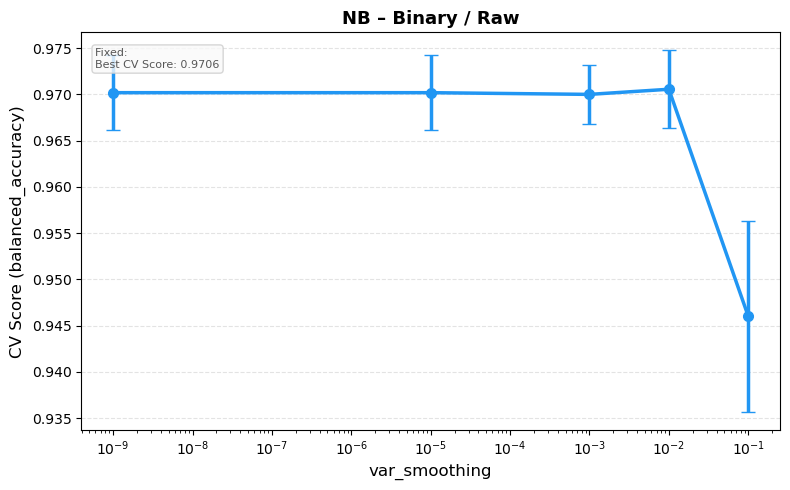

Saved: d:\CSE5104-Data Mining\eeg-ml-benchmark-suite\Model_NaiveBayes\..\Results\NB\Binary_Raw\CV_NB_Binary_Raw.png
Saved: d:\CSE5104-Data Mining\eeg-ml-benchmark-suite\Model_NaiveBayes\..\Results\NB\Binary_Raw\CV_NB_Binary_Raw.csv


In [ ]:
PLOTS_DIR = os.path.join(RESULTS_DIR, 'NB', 'Binary_Raw')
os.makedirs(PLOTS_DIR, exist_ok=True)

slc, fixed_str, best_score = best_slice('Binary', 'Raw')

fig, ax = plt.subplots(figsize=(8, 5))
slc = slc.sort_values(MAIN_PARAM)
ax.errorbar(slc[MAIN_PARAM], slc['mean_test_score'], yerr=slc['std_test_score'],
            marker='o', color='#2196F3', linewidth=2.5, capsize=5, markersize=7)
ax.set_xscale("log")

ax.set_xlabel(MAIN_LABEL, fontsize=12)
ax.set_ylabel('CV Score (balanced_accuracy)', fontsize=12)
ax.set_title('NB – Binary / Raw', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.35, linestyle='--')

ax.annotate(f'Fixed: {fixed_str}\nBest CV Score: {best_score:.4f}',
            xy=(0.02, 0.96), xycoords='axes fraction', va='top',
            fontsize=8, color='#555555',
            bbox=dict(boxstyle='round,pad=0.3', fc='#f9f9f9', ec='#cccccc', alpha=0.8))

plt.tight_layout()
out = os.path.join(PLOTS_DIR, 'CV_NB_Binary_Raw.png')
plt.savefig(out, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

csv_name = 'CV_NB_Binary_Raw.png'.replace('.png', '.csv')
csv_out = os.path.join(PLOTS_DIR, csv_name)
slc.to_csv(csv_out, index=False)
print(f'Saved: {csv_out}')

## Binary / Reduced

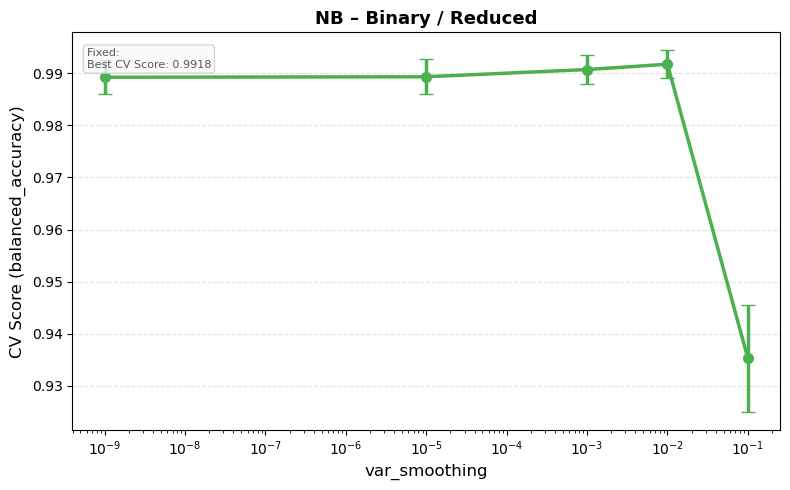

Saved: d:\CSE5104-Data Mining\eeg-ml-benchmark-suite\Model_NaiveBayes\..\Results\NB\Binary_Reduced\CV_NB_Binary_Reduced.png
Saved: d:\CSE5104-Data Mining\eeg-ml-benchmark-suite\Model_NaiveBayes\..\Results\NB\Binary_Reduced\CV_NB_Binary_Reduced.csv


In [4]:
PLOTS_DIR = os.path.join(RESULTS_DIR, 'NB', 'Binary_Reduced')
os.makedirs(PLOTS_DIR, exist_ok=True)

slc, fixed_str, best_score = best_slice('Binary', 'Reduced')

fig, ax = plt.subplots(figsize=(8, 5))
slc = slc.sort_values(MAIN_PARAM)
ax.errorbar(slc[MAIN_PARAM], slc['mean_test_score'], yerr=slc['std_test_score'],
            marker='o', color='#4CAF50', linewidth=2.5, capsize=5, markersize=7)
ax.set_xscale("log")

ax.set_xlabel(MAIN_LABEL, fontsize=12)
ax.set_ylabel('CV Score (balanced_accuracy)', fontsize=12)
ax.set_title('NB – Binary / Reduced', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.35, linestyle='--')

ax.annotate(f'Fixed: {fixed_str}\nBest CV Score: {best_score:.4f}',
            xy=(0.02, 0.96), xycoords='axes fraction', va='top',
            fontsize=8, color='#555555',
            bbox=dict(boxstyle='round,pad=0.3', fc='#f9f9f9', ec='#cccccc', alpha=0.8))

plt.tight_layout()
out = os.path.join(PLOTS_DIR, 'CV_NB_Binary_Reduced.png')
plt.savefig(out, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

csv_name = 'CV_NB_Binary_Reduced.png'.replace('.png', '.csv')
csv_out  = os.path.join(PLOTS_DIR, csv_name)
slc.to_csv(csv_out, index=False)
print(f'Saved: {csv_out}')


## Multiclass / Raw

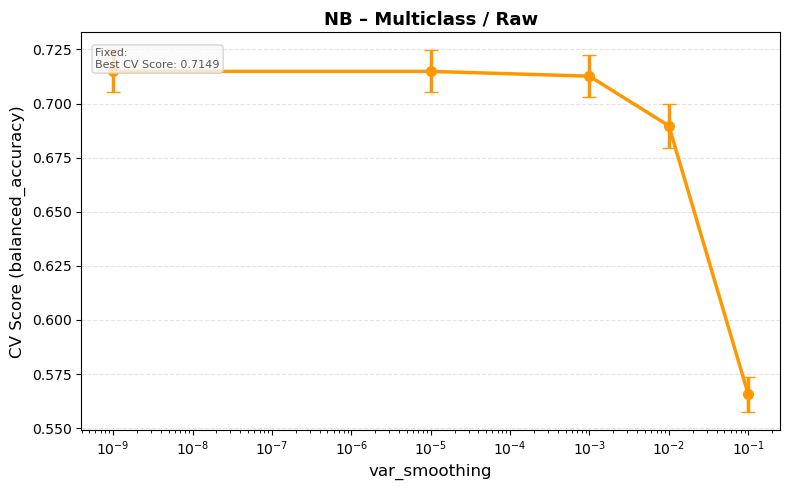

Saved: d:\CSE5104-Data Mining\eeg-ml-benchmark-suite\Model_NaiveBayes\..\Results\NB\Multiclass_Raw\CV_NB_Multiclass_Raw.png
Saved: d:\CSE5104-Data Mining\eeg-ml-benchmark-suite\Model_NaiveBayes\..\Results\NB\Multiclass_Raw\CV_NB_Multiclass_Raw.csv


In [5]:
PLOTS_DIR = os.path.join(RESULTS_DIR, 'NB', 'Multiclass_Raw')
os.makedirs(PLOTS_DIR, exist_ok=True)

slc, fixed_str, best_score = best_slice('Multiclass', 'Raw')

fig, ax = plt.subplots(figsize=(8, 5))
slc = slc.sort_values(MAIN_PARAM)
ax.errorbar(slc[MAIN_PARAM], slc['mean_test_score'], yerr=slc['std_test_score'],
            marker='o', color='#FF9800', linewidth=2.5, capsize=5, markersize=7)
ax.set_xscale("log")

ax.set_xlabel(MAIN_LABEL, fontsize=12)
ax.set_ylabel('CV Score (balanced_accuracy)', fontsize=12)
ax.set_title('NB – Multiclass / Raw', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.35, linestyle='--')

ax.annotate(f'Fixed: {fixed_str}\nBest CV Score: {best_score:.4f}',
            xy=(0.02, 0.96), xycoords='axes fraction', va='top',
            fontsize=8, color='#555555',
            bbox=dict(boxstyle='round,pad=0.3', fc='#f9f9f9', ec='#cccccc', alpha=0.8))

plt.tight_layout()
out = os.path.join(PLOTS_DIR, 'CV_NB_Multiclass_Raw.png')
plt.savefig(out, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

csv_name = 'CV_NB_Multiclass_Raw.png'.replace('.png', '.csv')
csv_out  = os.path.join(PLOTS_DIR, csv_name)
slc.to_csv(csv_out, index=False)
print(f'Saved: {csv_out}')


## Multiclass / Reduced

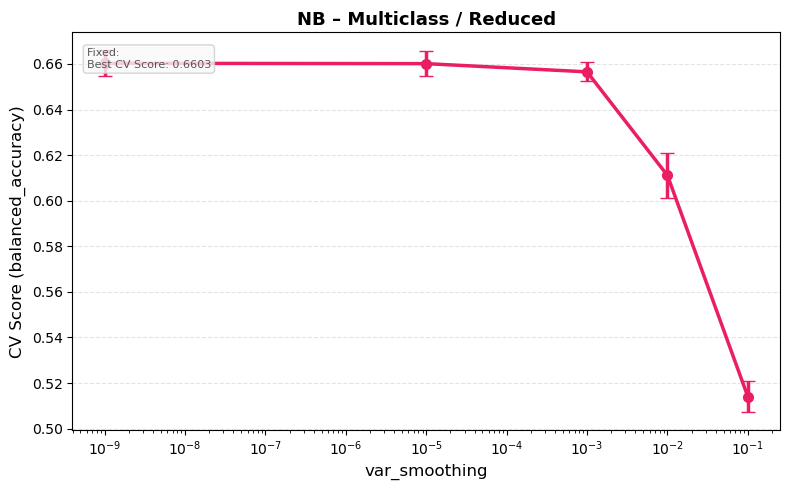

Saved: d:\CSE5104-Data Mining\eeg-ml-benchmark-suite\Model_NaiveBayes\..\Results\NB\Multiclass_Reduced\CV_NB_Multiclass_Reduced.png
Saved: d:\CSE5104-Data Mining\eeg-ml-benchmark-suite\Model_NaiveBayes\..\Results\NB\Multiclass_Reduced\CV_NB_Multiclass_Reduced.csv


In [6]:
PLOTS_DIR = os.path.join(RESULTS_DIR, 'NB', 'Multiclass_Reduced')
os.makedirs(PLOTS_DIR, exist_ok=True)

slc, fixed_str, best_score = best_slice('Multiclass', 'Reduced')

fig, ax = plt.subplots(figsize=(8, 5))
slc = slc.sort_values(MAIN_PARAM)
ax.errorbar(slc[MAIN_PARAM], slc['mean_test_score'], yerr=slc['std_test_score'],
            marker='o', color='#E91E63', linewidth=2.5, capsize=5, markersize=7)
ax.set_xscale("log")

ax.set_xlabel(MAIN_LABEL, fontsize=12)
ax.set_ylabel('CV Score (balanced_accuracy)', fontsize=12)
ax.set_title('NB – Multiclass / Reduced', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.35, linestyle='--')

ax.annotate(f'Fixed: {fixed_str}\nBest CV Score: {best_score:.4f}',
            xy=(0.02, 0.96), xycoords='axes fraction', va='top',
            fontsize=8, color='#555555',
            bbox=dict(boxstyle='round,pad=0.3', fc='#f9f9f9', ec='#cccccc', alpha=0.8))

plt.tight_layout()
out = os.path.join(PLOTS_DIR, 'CV_NB_Multiclass_Reduced.png')
plt.savefig(out, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

csv_name = 'CV_NB_Multiclass_Reduced.png'.replace('.png', '.csv')
csv_out  = os.path.join(PLOTS_DIR, csv_name)
slc.to_csv(csv_out, index=False)
print(f'Saved: {csv_out}')
